In [13]:
import os
import random
import time
import h5py
import numpy as np
import pandas as pd
import scipy.io
import librosa
import kagglehub
import h5py
import shutil
import IPython.display as ipd
import matplotlib.pyplot as plt

from IPython.display import display, Audio
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score 
#from sktime.classification.kernel_based import RocketClassifier
from sktime.transformations.panel.rocket import Rocket
from sklearn.model_selection import GroupKFold
from sklearn.metrics import classification_report
from detach_rocket.detach_classes import DetachRocket
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sktime.classification.kernel_based import RocketClassifier


In [14]:
# ==================================================
# 2. CARGA Y CONCATENACIÓN DE BABBLE NOISE (LOCAL)
# ==================================================
babble_exact_path = "datasets/noise/0dB/valid/real" 

audio_buffers_list = []
max_archivos_a_combinar = 40 
sr_original = 16000
sr_objetivo = 22050

archivos_mat = 0

for f in os.listdir(babble_exact_path):
    if len(audio_buffers_list) >= max_archivos_a_combinar:
        break

    file_path = os.path.join(babble_exact_path, f)
    
    if file_path.endswith('.mat'):
            mat_contents = scipy.io.loadmat(file_path) #esta funcion convierte el .mat en un diccionario 
            keys = [k for k in mat_contents.keys() if not k.startswith('__')] # cuando SciPy lee un .mat, automáticamente le inyecta variables internas de configuración que siempre empiezan con doble guion bajo (ej: __header. 
            #armo una lista solo con los nombres de las variables "reales" que contienen el audio
            if keys:
                audio_raw = mat_contents[keys[0]].flatten().astype(np.float32) 
                #mat_contents[keys[0]] extrae los datos almacenados en la primera clave válida
                # .flatten(): "aplasta" esa matriz para convertirla en un vector 1D
                # .astype(np.float32): conversión a formato decimal de 32 bits (float32).
                if audio_raw.size > 0:
                    audio_buffers_list.append(audio_raw)
                    archivos_mat += 1

# Procesamiento final
print("-" * 50)
print(f" - Archivos .mat procesados: {archivos_mat}")



--------------------------------------------------
 - Archivos .mat procesados: 40


In [15]:
babble_completo_16k = np.concatenate(audio_buffers_list)
babble_audio_full = librosa.resample(babble_completo_16k, orig_sr=sr_original, target_sr=sr_objetivo) #la paso a la sample rate que necesito

In [16]:
# ==================================================
# 3. FUNCIONES DE DATA AUGMENTATION
# ==================================================

#RUIDO BLANCO
def add_white_noise(audio, noise_level=0.005):
    noise = np.random.randn(len(audio)) #vector de numeros aleatorios con la misma longitud que mi vector original
    return audio + noise_level * noise

In [17]:
#RUIDO ROSA
def add_pink_noise(audio, noise_level=0.01):
    #el ruido rosa se caracteriza por tener una densidad espectral inversa a la frecuencia (es decir, 1/f)
    white = np.random.randn(len(audio)) #genero ruido blanco
    fft_white = np.fft.rfft(white) #transformada de fourier - paso el ruido blanco a dominio de la frecuencia. Ya no es la potencia, es la amplitud la que veo representada
    frequencies = np.maximum(np.fft.rfftfreq(len(audio)), 1e-10) #crea un vector de frecuencias. SI hay un valor menor a 1e-10, lo reemplaza por este número.
    #Elijo 1e-10 porque es un numero cercano a cero, sin ser cero.
    f_filter = 1.0 / np.sqrt(frequencies) #En la línea anterior, me aseguré de que no queden divisiones por cero. V^2 = P -> 1/sqrt(f) = P (ver notas)
    f_filter /= np.max(f_filter) #Busca el numero mas grande que haya quedado dentro del array y divide a todos los valores por este numero
    fft_pink = fft_white * f_filter #Aplica el filtro al ruido blanco en el dominio de la frecuencia.
    pink = np.fft.irfft(fft_pink, n=len(audio)) #Conversion al dominio del tiempo
    pink = pink / np.max(np.abs(pink)) #normalizacion
    return audio + noise_level * pink

In [18]:

#MULTITALKER BABBLE NOISE 
def add_babble_noise(audio, babble_audio, noise_level=0.03):
    # np.tile -> construye un nuevo array repitiendo el primer argumento (en este caso, babble_audio) la cantidad de veces que se pida. 
    # Esto se aplica solo si el audio es menor al audio original  
    #np.ceil -> devuelve el menor escalar i tal que i>=x
    if len(babble_audio) < len(audio):
        babble_audio = np.tile(babble_audio, int(np.ceil(len(audio) / len(babble_audio))))

    # toma un punto de inicio random
    start_idx = random.randint(0, len(babble_audio) - len(audio))
    babble_chunk = babble_audio[start_idx : start_idx + len(audio)] #aplico babble noise desde mi punto random hasta el final del audio
    babble_chunk = babble_chunk / (np.max(np.abs(babble_chunk)) + 1e-10) #normalizo el murmullo para que no haya picos de volumen descontrolados

    return audio + noise_level * babble_chunk 


In [19]:
# ==========================================
# 4. DESCARGA Y CURACIÓN DEL DATASET LOCAL
# ==========================================
dataset_root_path = kagglehub.dataset_download("mmoreaux/environmental-sound-classification-50")

metadata_path = None
for root, dirs, files in os.walk(dataset_root_path):
    if 'esc50.csv' in files:
        metadata_path = os.path.join(root, 'esc50.csv')
        break

if metadata_path:
    df = pd.read_csv(metadata_path)
    print("Archivo de metadatos cargado correctamente.")

mis_clases = ['clock_alarm', 'door_wood_knock', 'cat', 'crying_baby', 'dog', 'glass_breaking']
df_filtrado = df[df['category'].isin(mis_clases)].copy()

kaggle_audio_dir = None
for root, dirs, files in os.walk(dataset_root_path): #Busca donde estan los archivos
    if any(f.endswith('.wav') for f in files):
        kaggle_audio_dir = root
        break

target_dir = "datasets/audios_originales"
archivos_copiados = 0

for index, row in df_filtrado.iterrows():
    src_path = os.path.join(kaggle_audio_dir, row['filename'])
    dst_path = os.path.join(target_dir, row['filename'])
    
    # Solo lo copio si el archivo original existe y no esta en el directorio audios_originales
    if os.path.exists(src_path) and not os.path.exists(dst_path):
        shutil.copy2(src_path, dst_path)
        archivos_copiados += 1

print(f"Se copiaron {archivos_copiados} archivos nuevos.")


Archivo de metadatos cargado correctamente.
Se copiaron 0 archivos nuevos.


In [20]:
# ==========================================
# 5. TRANSFORMACIÓN A MFCC Y DATA AUGMENTATION. 
# Paso a espectograma
# ==========================================
correct_audio_dir = target_dir 

X_list = []
y_list = []
groups = []

n_mfcc = 40 #Se puede jugar con este valor. representa la cantidad de caracteristicas acusticas (coef) que librosa 
#extrajo en un instante de t para imitar como percibe el oido humano el audio.

hop_length = 512

for index, row in df_filtrado.iterrows(): 
    file_path = os.path.join(correct_audio_dir, row['filename']) 
    categoria = row['category'] 
    
    y_audio, sr = librosa.load(file_path, sr=22050) 

    audios_a_procesar = [
            y_audio,                                     
            add_white_noise(y_audio),                    
            add_pink_noise(y_audio),                     
            add_babble_noise(y_audio, babble_audio_full) 
        ]

    # Convertir a MFCC
    for audio_version in audios_a_procesar:
        mfccs = librosa.feature.mfcc(y=audio_version, sr=sr, n_mfcc=n_mfcc, hop_length=hop_length)
        
        X_list.append(mfccs)
        y_list.append(categoria)
        groups.append(row['filename'])

X = np.array(X_list)
y = np.array(y_list)
groups = np.array(groups)

print("-" * 50)
print(f"Forma final de la matriz X: {X.shape}") #(960, 40, 216) (cantidad de muestras, variables, ventanas de tiempo)
print(f"Cantidad de etiquetas y: {y.shape}")

--------------------------------------------------
Forma final de la matriz X: (960, 40, 216)
Cantidad de etiquetas y: (960,)


In [21]:
# ==========================================
# 6. ENTRENAMIENTO ROCKET / DETACH ROCKET CON MFCC
# ==========================================

le = LabelEncoder()
y_encoded = le.fit_transform(y)

gkf = GroupKFold(n_splits=5) 

accuracies = []
all_y_true = []
all_y_pred = []

print("-" * 50)
print(f"Total de muestras aumentadas: {len(X)}")
print(f"Forma de entrada al modelo: {X.shape} (muestras, coeficientes, tiempo)")

for fold, (train_index, test_index) in enumerate(gkf.split(X, y_encoded, groups=groups)): 
    print(f"\n INICIANDO FOLD {fold+1} DE 5")
    
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y_encoded[train_index], y_encoded[test_index]
    
    kernels_a_usar = 5000
    print(f"   [{time.strftime('%H:%M:%S')}] Entrenando Rocket con {kernels_a_usar} kernels...")
    
    start_time = time.time()
    
    # Al pasarle el parámetro, anula la aleatoriedad y usa los 84 kernels optimizados
    modelo = RocketClassifier(rocket_transform="minirocket") #usa 84 kernels optimizados

    modelo.fit(X_train, y_train)
    
    tiempo_entrenamiento = (time.time() - start_time) / 60
    print(f"   Entrenamiento listo. Tardó: {tiempo_entrenamiento:.2f} minutos.")
    
    # Predicción y Evaluación
    y_pred = modelo.predict(X_test)
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    
    print(f" - Fold {fold+1}: Accuracy = {acc:.4f}")

# Resultado final
print("\n" + "=" * 50)
print(f"ACCURACY PROMEDIO FINAL: {np.mean(accuracies):.4f}")
print("=" * 50)



--------------------------------------------------
Total de muestras aumentadas: 960
Forma de entrada al modelo: (960, 40, 216) (muestras, coeficientes, tiempo)

 INICIANDO FOLD 1 DE 5
   [18:01:01] Entrenando Rocket con 5000 kernels...
   Entrenamiento listo. Tardó: 0.10 minutos.
 - Fold 1: Accuracy = 0.9219

 INICIANDO FOLD 2 DE 5
   [18:01:08] Entrenando Rocket con 5000 kernels...
   Entrenamiento listo. Tardó: 0.09 minutos.
 - Fold 2: Accuracy = 0.9271

 INICIANDO FOLD 3 DE 5
   [18:01:15] Entrenando Rocket con 5000 kernels...
   Entrenamiento listo. Tardó: 0.09 minutos.
 - Fold 3: Accuracy = 0.9427

 INICIANDO FOLD 4 DE 5
   [18:01:21] Entrenando Rocket con 5000 kernels...
   Entrenamiento listo. Tardó: 0.09 minutos.
 - Fold 4: Accuracy = 0.9219

 INICIANDO FOLD 5 DE 5
   [18:01:28] Entrenando Rocket con 5000 kernels...
   Entrenamiento listo. Tardó: 0.09 minutos.
 - Fold 5: Accuracy = 0.8542

ACCURACY PROMEDIO FINAL: 0.9135


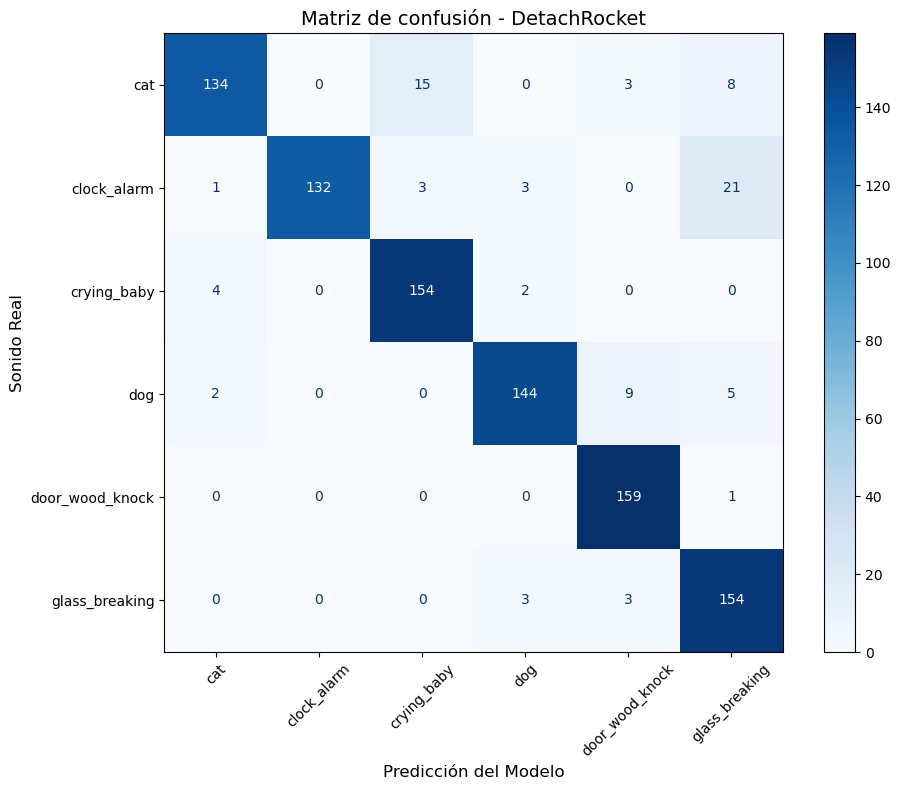

In [22]:
# ==========================================
# 7. MATRIZ DE CONFUSION
# ==========================================

cm = confusion_matrix(all_y_true, all_y_pred)

# Recuperamos los nombres originales de las etiquetas (ej: 'dog', 'siren', etc.)
nombres_clases = le.classes_ 

# Graficamos
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nombres_clases)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)

plt.title('Matriz de confusión - DetachRocket', fontsize=14)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Sonido Real', fontsize=12)
plt.tight_layout()
plt.show()

In [23]:
# ==========================================
# 8. EXPORTAR MODELO
# ==========================================

import joblib

joblib.dump(modelo, 'mini_rocket_modelo_exportado.pkl')
joblib.dump(le, 'label_encoder.pkl')


['label_encoder.pkl']